In [1]:
import pandas as pd
from pathlib import Path
import os
import numpy as np

In [2]:
BASE_DIR=Path(os.getcwd())
FILTERED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"filtered"
PROCESSED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"processed"
OUTPUTS_DIR=BASE_DIR/"brd4_pipeline"/"outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

df=pd.read_csv(FILTERED_DIR/"brd4_druglike.csv")

morgan_fps=np.load(PROCESSED_DIR/"brd4_morgan_fp.npy")
print(f"[INFO] molecules loaded : {len(df):,}")
print(f"[INFO] Fingerprint matrix : {morgan_fps.shape}")
print(f"[INFO] pIC50 range : {df['pIC50'].min():.2f} - {df['pIC50'].max():.2f}")

[INFO] molecules loaded : 2,210
[INFO] Fingerprint matrix : (2210, 2048)
[INFO] pIC50 range : 3.59 - 10.92


PCA completed,
 PC1 explains 1.8% of variance
 PC2 explains 1.4% of variance
 Combined 3.2% of variance


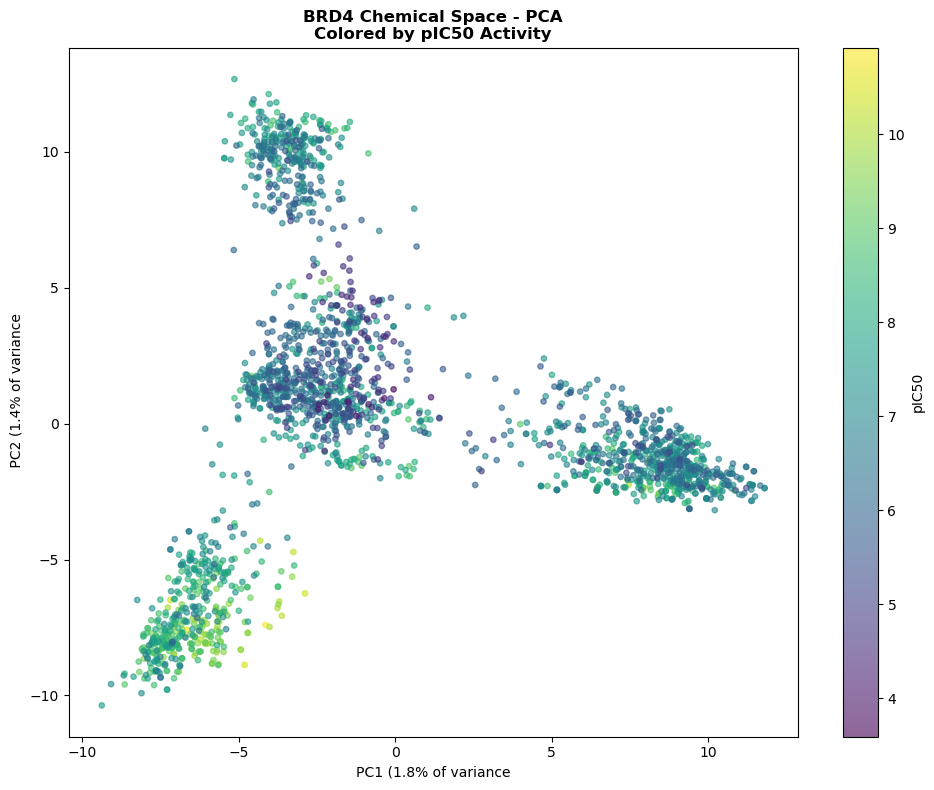

[SAVED] PCA plot saved


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm

scaler=StandardScaler()
fps_scaled=scaler.fit_transform(morgan_fps)

pca=PCA(n_components=2, random_state=42)
pca_coords=pca.fit_transform(fps_scaled)

print(f"PCA completed,")
print(f" PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f" PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f" Combined {sum(pca.explained_variance_ratio_)*100:.1f}% of variance")

fig, ax =plt.subplots(figsize=(10,8))

scatter =ax.scatter(
    pca_coords[:,0],
    pca_coords[:,1],
    c=df['pIC50'],
    cmap='viridis',
    alpha=0.6,
    s=15)

plt.colorbar(scatter, ax=ax, label='pIC50')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance')
ax.set_ylabel(f' PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance')
ax.set_title('BRD4 Chemical Space - PCA\nColored by pIC50 Activity', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR/"module04_pca.png", dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] PCA plot saved")

Applicability Domain (AD) boundaries:
  PC1 range: -17.66 to 17.66
  PC2 range: -15.42 to 15.42

  Inside AD  : 2,210 molecules (100.0%)
  Outside AD : 0 molecules (0.0%)


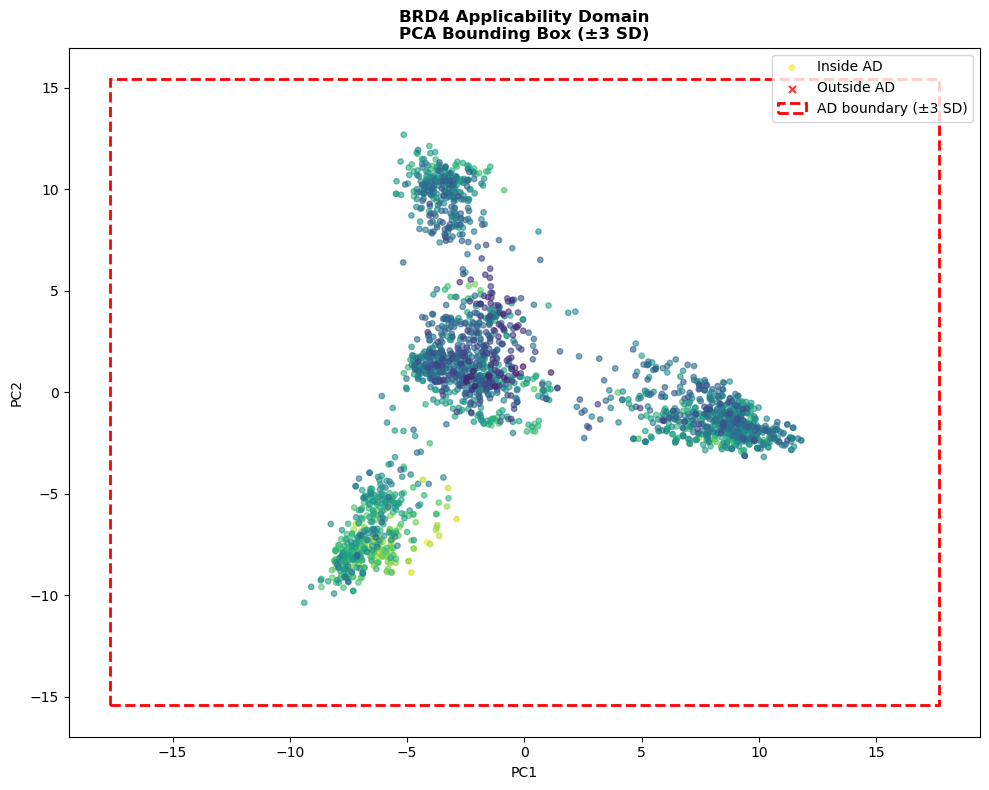

[SAVED] Applicability Domain plot saved.
[SAVED] AD parameters: C:\Users\raksh\brd4_pipeline\data\processed\brd4_ad_params.json


In [5]:
pc1_mean = pca_coords[:, 0].mean()
pc1_std  = pca_coords[:, 0].std()
pc2_mean = pca_coords[:, 1].mean()
pc2_std  = pca_coords[:, 1].std()

pc1_lower = pc1_mean - 3 * pc1_std
pc1_upper = pc1_mean + 3 * pc1_std
pc2_lower = pc2_mean - 3 * pc2_std
pc2_upper = pc2_mean + 3 * pc2_std

print("Applicability Domain (AD) boundaries:")
print(f"  PC1 range: {pc1_lower:.2f} to {pc1_upper:.2f}")
print(f"  PC2 range: {pc2_lower:.2f} to {pc2_upper:.2f}")

inside_ad = (
    (pca_coords[:, 0] >= pc1_lower) &
    (pca_coords[:, 0] <= pc1_upper) &
    (pca_coords[:, 1] >= pc2_lower) &
    (pca_coords[:, 1] <= pc2_upper)
)

n_inside  = inside_ad.sum()
n_outside = (~inside_ad).sum()
print(f"\n  Inside AD  : {n_inside:,} molecules ({n_inside/len(df)*100:.1f}%)")
print(f"  Outside AD : {n_outside:,} molecules ({n_outside/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(pca_coords[inside_ad, 0],  pca_coords[inside_ad, 1],
           c=df['pIC50'][inside_ad], cmap='viridis',
           alpha=0.6, s=15, label='Inside AD')

ax.scatter(pca_coords[~inside_ad, 0], pca_coords[~inside_ad, 1],
           c='red', alpha=0.8, s=25, marker='x', label='Outside AD')

from matplotlib.patches import Rectangle
rect = Rectangle(
    (pc1_lower, pc2_lower),
    pc1_upper - pc1_lower,            
    pc2_upper - pc2_lower,            
    linewidth=2, edgecolor='red',
    facecolor='none', linestyle='--',
    label='AD boundary (±3 SD)'
)
ax.add_patch(rect)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('BRD4 Applicability Domain\nPCA Bounding Box (±3 SD)',
             fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "module04_applicability_domain.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] Applicability Domain plot saved.")

ad_params = {
    'pc1_mean'  : pc1_mean,
    'pc1_std'   : pc1_std,
    'pc2_mean'  : pc2_mean,
    'pc2_std'   : pc2_std,
    'pc1_lower' : pc1_lower,
    'pc1_upper' : pc1_upper,
    'pc2_lower' : pc2_lower,
    'pc2_upper' : pc2_upper
}

import json
ad_file = PROCESSED_DIR / "brd4_ad_params.json"
with open(ad_file, 'w') as f:
    json.dump(ad_params, f, indent=2)
print(f"[SAVED] AD parameters: {ad_file}")

[INFO] Running UMAP dimensionality reduction...
[INFO] This may take 2-3 minutes. Do not interrupt.


C:\Users\raksh\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[DONE] UMAP completed. Output shape: (2210, 2)


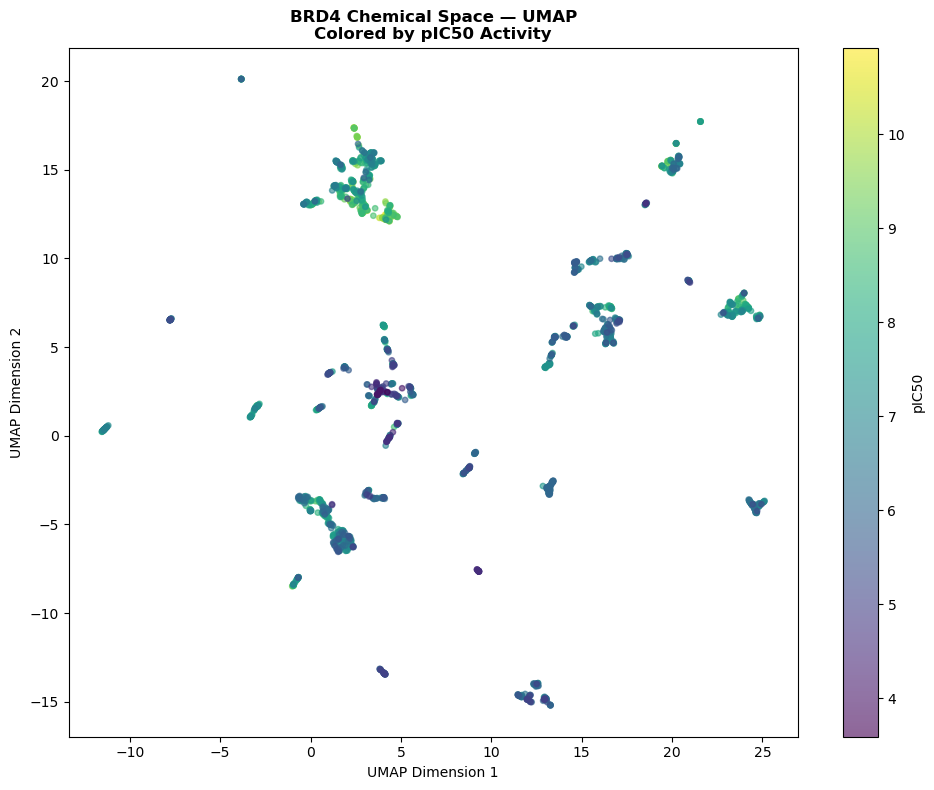

[SAVED] UMAP plot saved.


In [6]:
import umap
import matplotlib.pyplot as plt

print("[INFO] Running UMAP dimensionality reduction...")
print("[INFO] This may take 2-3 minutes. Do not interrupt.")


reducer    = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

umap_coords = reducer.fit_transform(morgan_fps)

print(f"[DONE] UMAP completed. Output shape: {umap_coords.shape}")

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    umap_coords[:, 0],
    umap_coords[:, 1],
    c=df['pIC50'],
    cmap='viridis',
    alpha=0.6,
    s=15
)

plt.colorbar(scatter, ax=ax, label='pIC50')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.set_title('BRD4 Chemical Space — UMAP\nColored by pIC50 Activity',
             fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "module04_umap.png", dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] UMAP plot saved.")

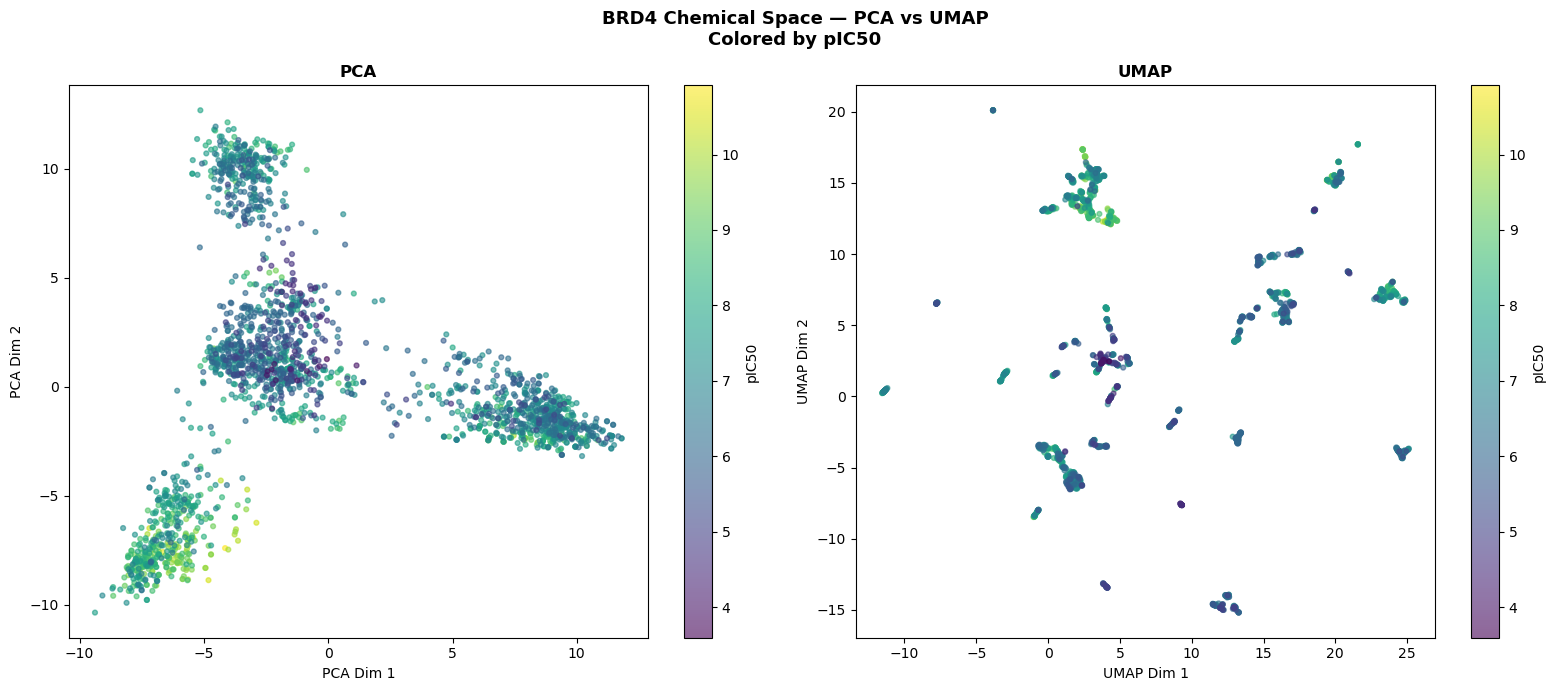

[SAVED] Comparison plot saved.
  MODULE 4 — PIPELINE AUDIT REPORT
  Target: BRD4 (CHEMBL4523)
  Molecules visualized       : 2,210

  PCA variance explained:
    PC1 : 1.8%
    PC2 : 1.4%
    Sum : 3.2%

  Applicability Domain:
    Inside AD  : 2,210 (100.0%)
    Outside AD : 0 (0.0%)

  Files saved:
  outputs/    module04_pca.png
  outputs/    module04_applicability_domain.png
  outputs/    module04_umap.png
  outputs/    module04_pca_vs_umap.png
  processed/  brd4_ad_params.json
  Module 4 complete.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('BRD4 Chemical Space — PCA vs UMAP\nColored by pIC50',
             fontsize=13, fontweight='bold')

for ax, coords, title in zip(
    axes,
    [pca_coords, umap_coords],
    ['PCA', 'UMAP']
):
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=df['pIC50'], cmap='viridis',
                    alpha=0.6, s=12)
    plt.colorbar(sc, ax=ax, label='pIC50')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'{title} Dim 1')
    ax.set_ylabel(f'{title} Dim 2')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "module04_pca_vs_umap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] Comparison plot saved.")

print("=" * 55)
print("  MODULE 4 — PIPELINE AUDIT REPORT")
print("  Target: BRD4 (CHEMBL4523)")
print("=" * 55)
print(f"  Molecules visualized       : {len(df):,}")
print()
print(f"  PCA variance explained:")
print(f"    PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"    PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"    Sum : {sum(pca.explained_variance_ratio_)*100:.1f}%")
print()
print(f"  Applicability Domain:")
print(f"    Inside AD  : {n_inside:,} ({n_inside/len(df)*100:.1f}%)")
print(f"    Outside AD : {n_outside:,} ({n_outside/len(df)*100:.1f}%)")
print()
print("  Files saved:")
print("  outputs/    module04_pca.png")
print("  outputs/    module04_applicability_domain.png")
print("  outputs/    module04_umap.png")
print("  outputs/    module04_pca_vs_umap.png")
print("  processed/  brd4_ad_params.json")
print("=" * 55)
print("  Module 4 complete.")
print("=" * 55)